In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
def sigmoid(x,A,a,c):
    return A/(1+np.exp(-a*(x-6))) + c
    
def sigma_a(nu_rest):
    Lam_a = 6.255486e8 ## Hz
    nu_lya = 2.46607e15 ## Hz
    C = 6.9029528e22 ## Ang2/s2
    sig = C *(nu_rest/nu_lya)**4 / (4*np.pi**2 * (nu_rest - nu_lya)**2 +  Lam_a**2*(nu_rest/nu_lya)**6/4)
    s = sig * 1e-16 ## convert AA-2 to cm-2
    return s


def tau_cgm(N_HI, lam, z):
        lam_rest = lam/(1+z)
        nu_rest = 3e18/lam_rest
        tau = np.zeros(len(lam))
        for i, nu in enumerate(nu_rest):
            tau[i] = N_HI * sigma_a(nu)
        return tau
    
    
def lgNHI_z(z):
        A = 4.92919285
        a = 0.76313514
        c = 17.54936014
        lgN_HI = sigmoid(z,A,a,c)
        
        return lgN_HI
        
def cgm(z, lam):
    NHI = 10**(lgNHI_z(z))
    tau_C = tau_cgm(NHI, lam, z)
    return np.exp(- tau_C)

In [3]:
# test values sigmoid
val = [sigmoid(z,4.92919285,0.76313514,17.54936014) for z in range(16)]
print(val)

[17.599454325421615, 17.655575741288818, 17.77170576145825, 18.00286662798902, 18.429418447684405, 19.116675778763888, 20.013956565, 20.911237351236114, 21.598494682315597, 22.02504650201098, 22.25620736854175, 22.372337388711188, 22.428458804578387, 22.455071571095026, 22.467577985189465, 22.473430326691734]


In [4]:
#test values sigma_nu 
val = [sigma_a(nu*1000) for nu in range(10)]
print(val)

[0.0, 7.773968332535842e-76, 1.2438349332067436e-74, 6.296914349364247e-74, 1.9901358931340173e-73, 4.8587302078506614e-73, 1.0075062959007306e-72, 1.8665297966509376e-72, 3.1842174290247575e-72, 5.100500623009859e-72]


In [5]:
# test values cgm
val = cgm(7,np.array([(lbd+1)*1000 for lbd in range(10)]))
print(val)

[0.99724646 0.99912122 0.99948469 0.99960015 0.99962451 0.99958079
 0.99942533 0.99890562 0.99516866 0.97113428]


In [6]:
l = np.array(range(10000))

In [7]:
res_7 = cgm(7,l) 

/tmp/ipykernel_107888/480877320.py:15: RuntimeWarning: divide by zero encountered in divide
  nu_rest = 3e18/lam_rest
/tmp/ipykernel_107888/480877320.py:8: RuntimeWarning: invalid value encountered in scalar divide
  sig = C *(nu_rest/nu_lya)**4 / (4*np.pi**2 * (nu_rest - nu_lya)**2 +  Lam_a**2*(nu_rest/nu_lya)**6/4)


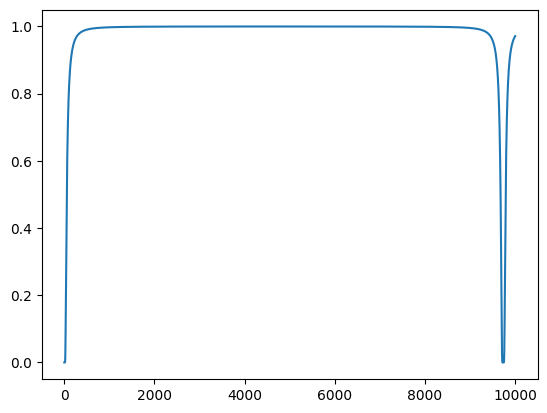

In [8]:
plt.plot(l, res_7)


In [1]:
from astropy.table import Table

In [2]:
inoue = Table.read('/home/dubathf/Phosphoros/Results/CANUCS_TECHNICOLOR/phot_canucs_zgt7.5_emline/phz_cat.fits')

In [3]:
inoue_ly=Table.read('/home/dubathf/Phosphoros/Results/CANUCS_TECHNICOLOR/LYA_INOUE/phz_cat.fits')

In [4]:
cgm=Table.read('/home/dubathf/Phosphoros/Results/CANUCS_TECHNICOLOR/INOUECGM/phz_cat.fits')
cgm_ly=Table.read('/home/dubathf/Phosphoros/Results/CANUCS_TECHNICOLOR/LYA_INOUECGM/phz_cat.fits')

In [13]:
i_m, i_b = np.polyfit(inoue['specz'],inoue['Z'], 1)
ily_m, ily_b = np.polyfit(inoue_ly['specz'],inoue_ly['Z'], 1)
c_m, c_b = np.polyfit(cgm['specz'],cgm['Z'], 1)
cly_m, cly_b = np.polyfit(cgm_ly['specz'],cgm_ly['Z'], 1)

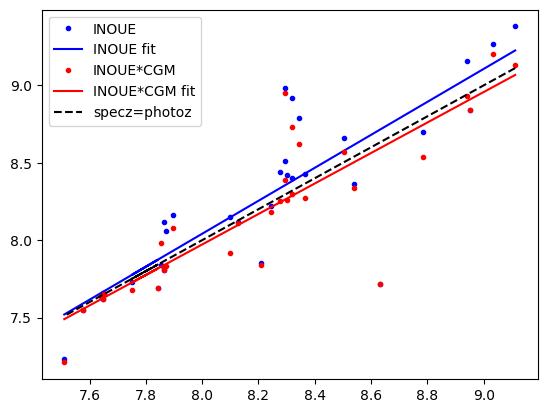

In [17]:
plt.plot(inoue['specz'],inoue['Z'],'b.', label="INOUE")
plt.plot(inoue['specz'],i_m*inoue['specz']+i_b,'b-', label="INOUE fit")

plt.plot(cgm['specz'],cgm['Z'],'r.', label="INOUE*CGM")
plt.plot(cgm['specz'],c_m*cgm['specz']+c_b,'r-', label="INOUE*CGM fit")
plt.plot(inoue['specz'],inoue['specz'],'k--', label="specz=photoz")
plt.legend()

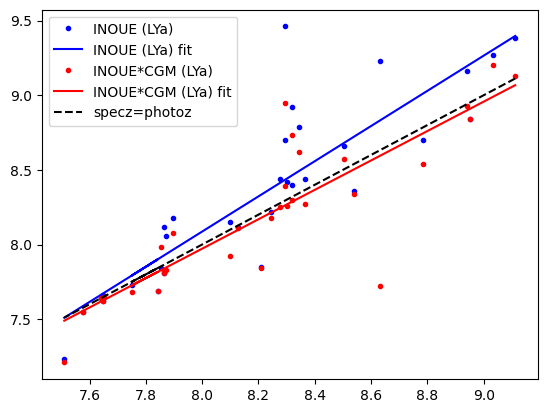

In [18]:
plt.plot(inoue['specz'],inoue_ly['Z'],'b.', label="INOUE (LYa)")
plt.plot(inoue['specz'],ily_m*inoue['specz']+ily_b,'b-', label="INOUE (LYa) fit")

plt.plot(cgm['specz'],cgm_ly['Z'],'r.', label="INOUE*CGM (LYa)")
plt.plot(cgm['specz'],cly_m*cgm['specz']+cly_b,'r-', label="INOUE*CGM (LYa) fit")
plt.plot(inoue['specz'],inoue['specz'],'k--', label="specz=photoz")
plt.legend()